<a href="https://colab.research.google.com/github/lailynissaam/Analisis-Deret-Waktu/blob/main/Hands_On_Minggu_6_STA2542_Pemodelan_dan_Peramalan_Data_Tidak_Stasioner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> MODEL TIDAK STASIONER </center></h1><center>Laily Nissa A.M </center>

<center>
_____________________________________________________________________________________________________________________________
</center>


In [1]:
!pip install PythonTsa

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.datasets import get_rdataset
from PythonTsa.plot_acf_pacf import acf_pacf_fig

import warnings
warnings.filterwarnings("ignore")

In [3]:
temperature=pd.read_csv('https://raw.githubusercontent.com/lailynissaam/Analisis-Deret-Waktu/refs/heads/main/data.csv')
temperature.head()

,Date,Temp
0,2000-01-01,0.26
1,2000-02-01,0.33
2,2000-03-01,0.32
3,2000-04-01,0.33
4,2000-05-01,0.32


In [4]:
temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    320 non-null    object 
 1   Temp    320 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.1+ KB


In [5]:
temperature['Date'] = pd.to_datetime(temperature['Date'])
temperature.set_index('Date', inplace=True)

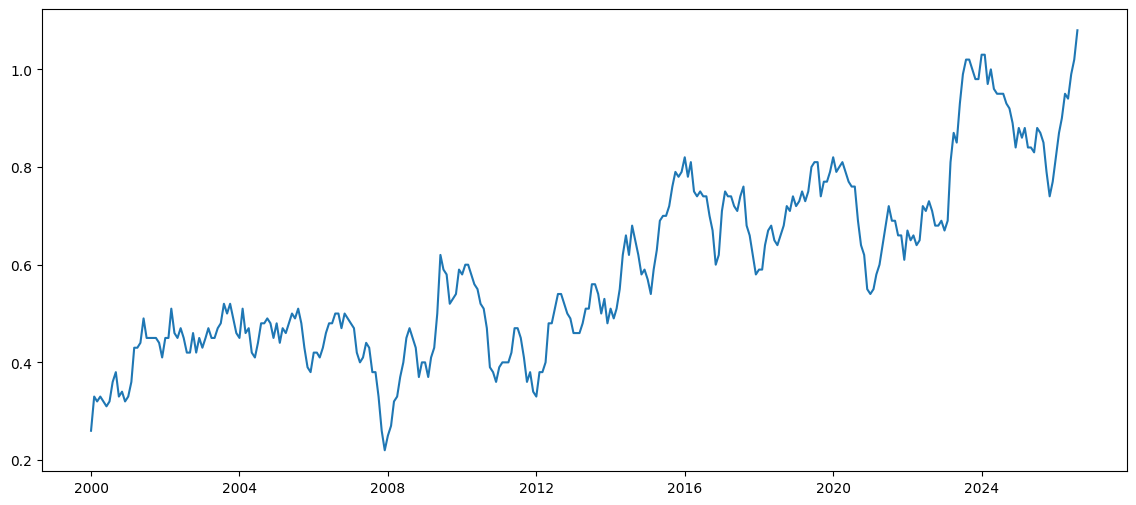

In [6]:
plt.figure(figsize=(14,6))
plt.plot(temperature); plt.show()

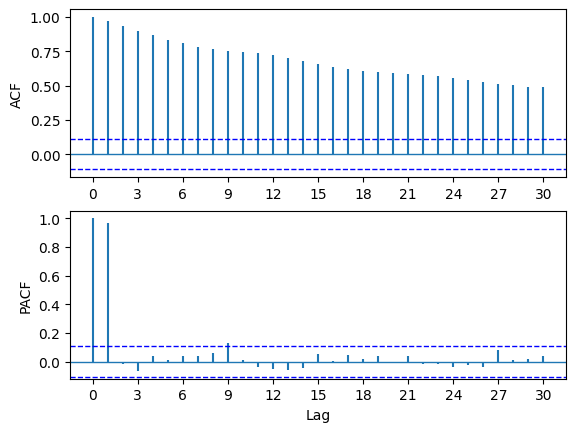

In [7]:
acf_pacf_fig(temperature, both=True, lag=30)

In [8]:
from statsmodels.tsa.stattools import adfuller
adfuller(temperature, autolag='AIC')[1]

0.8504334800210274

In [9]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(temperature.Temp, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.09303693158698725
interval kepercayaan lambda: (-0.23051570784563813, 0.4226078737621666)


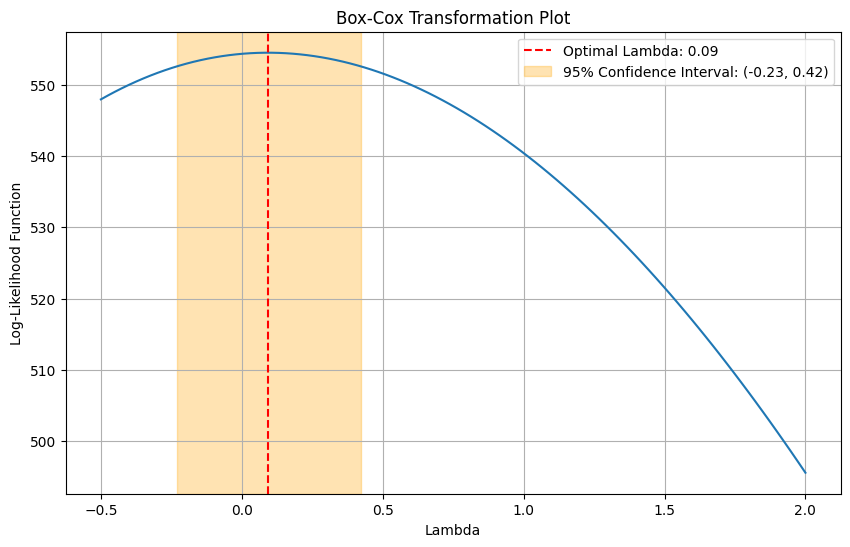

In [10]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, temperature.Temp) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

Penanganan deret tidak stasioner dengan urutan: penanganan tidak stasioner dalam ragam dilanjutkan penanganan dalam nilaitengah.

In [11]:
temperature_boxcox=pd.DataFrame(np.log(temperature.Temp))

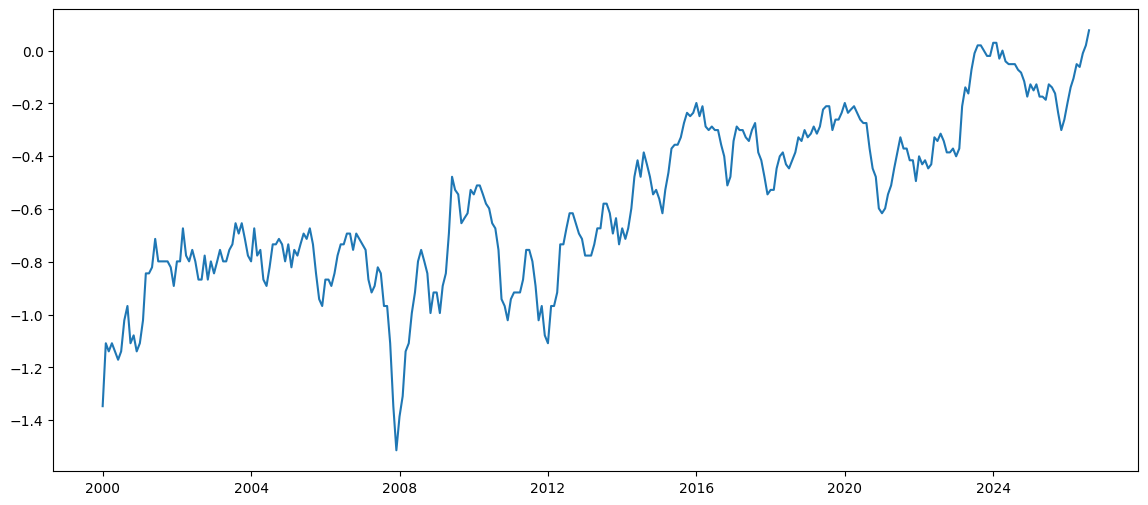

In [12]:
plt.figure(figsize=(14,6))
plt.plot(temperature_boxcox); plt.show()

In [13]:
temperature_boxcox.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 320 entries, 2000-01-01 to 2026-08-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    320 non-null    float64
dtypes: float64(1)
memory usage: 5.0 KB


In [14]:
temperature_boxcox['positif'] = temperature_boxcox['Temp'] - temperature_boxcox['Temp'].min() + 1

In [15]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(temperature_boxcox.positif, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  1.0901887304546483
interval kepercayaan lambda: (0.5046935868459135, 1.6987846785785101)


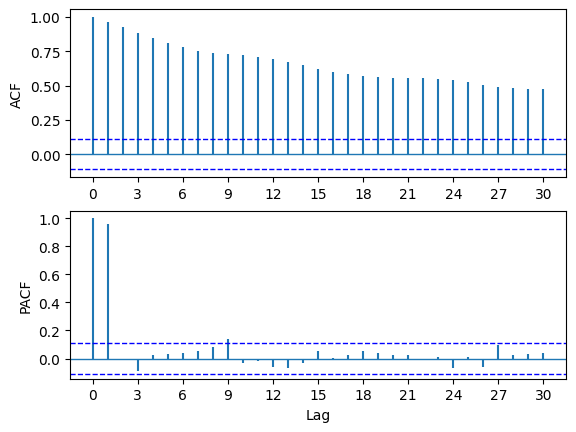

In [16]:
acf_pacf_fig(temperature_boxcox.Temp, both=True, lag=30)

In [17]:
temperature_diff=pd.DataFrame(temperature_boxcox.Temp.diff().dropna())

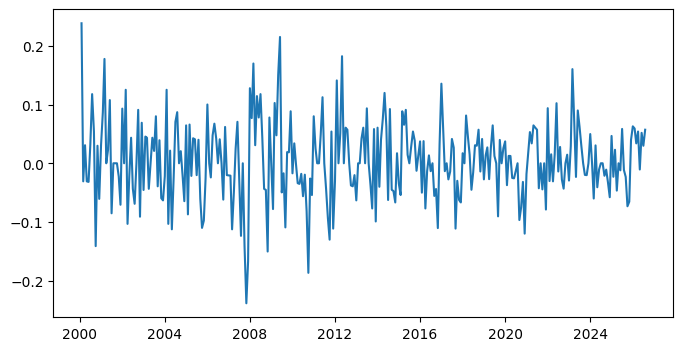

In [18]:
plt.figure(figsize=(8,4))
plt.plot(temperature_diff)
plt.show()

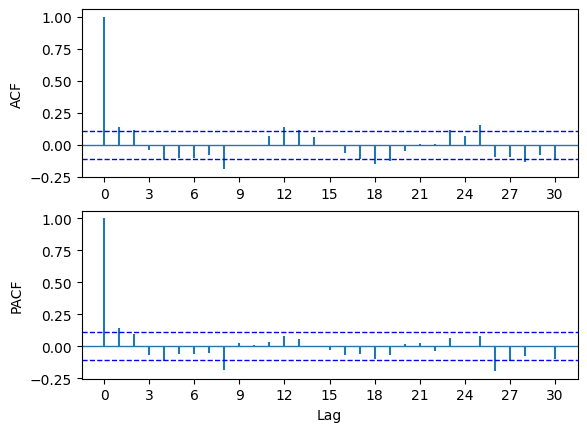

In [19]:
acf_pacf_fig(temperature_diff, both=True, lag=30)

In [20]:
adfuller(temperature_diff, autolag='AIC')[1]

1.1048582069753379e-14

In [21]:
from scipy.stats import boxcox,  boxcox_llf
temperature_diff['positif'] = temperature_diff['Temp'] - temperature_diff['Temp'].min() + 1
data,lambda_fit,ci=boxcox(temperature_diff.positif, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.7607486515378775
interval kepercayaan lambda: (-0.6657015540861985, 2.2025631268477492)


In [22]:
!pip install rpy2

In [23]:
%load_ext rpy2.ipython

In [24]:
%%R
install.packages('TSA')
library (TSA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/TSA_1.3.1.tar.gz'
Content type 'application/x-gzip' length 207505 bytes (202 KB)
downloaded 202 KB


The downloaded source packages are in
	‘/tmp/RtmpxSx8F9/downloaded_packages’

Attaching package: ‘TSA’

The following objects are masked from ‘package:stats’:

    acf, arima

The following object is masked from ‘package:utils’:

    tar



In [25]:
%%R -i temperature_diff.Temp
eacf(as.numeric(temperature_diff.Temp))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x x o o o o o x o o o  x  x  o 
1 x x o o o o o x o o o  o  o  o 
2 x x o o o o o x o o o  o  o  o 
3 x x x o o o o x o o o  o  o  o 
4 x x o o o o o x o o o  o  o  o 
5 x x o x o o o x o o o  o  o  o 
6 x o o x o x o x o o o  o  o  o 
7 x x o x x x x x o o o  o  o  o 


In [26]:
#model ARIMA (0,1,2)
model_arima1=ARIMA(temperature_boxcox.Temp,order=(0,1,2)).fit()

In [27]:
print(model_arima1.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  320
Model:                 ARIMA(0, 1, 2)   Log Likelihood                 422.370
Date:                Tue, 29 Sep 2026   AIC                           -838.741
Time:                        09:14:16   BIC                           -827.445
Sample:                    01-01-2000   HQIC                          -834.230
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1385      0.053      2.633      0.008       0.035       0.242
ma.L2          0.1533      0.049      3.156      0.002       0.058       0.248
sigma2         0.0041      0.000     14.421      0.0

In [28]:
#model ARIMA (1,1,2)
model_arima2=ARIMA(temperature_boxcox.Temp,order=(1,1,2)).fit()

In [29]:
print(model_arima2.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  320
Model:                 ARIMA(1, 1, 2)   Log Likelihood                 422.379
Date:                Tue, 29 Sep 2026   AIC                           -836.758
Time:                        09:14:17   BIC                           -821.697
Sample:                    01-01-2000   HQIC                          -830.743
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0349      0.306      0.114      0.909      -0.565       0.635
ma.L1          0.1052      0.308      0.341      0.733      -0.499       0.709
ma.L2          0.1503      0.064      2.349      0.0

In [30]:
#model ARIMA (2,1,2)
model_arima3=ARIMA(temperature_boxcox.Temp,order=(2,1,2)).fit()
print(model_arima3.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  320
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 423.716
Date:                Tue, 29 Sep 2026   AIC                           -837.431
Time:                        09:14:17   BIC                           -818.605
Sample:                    01-01-2000   HQIC                          -829.913
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3708      0.289      1.285      0.199      -0.195       0.936
ar.L2         -0.4640      0.211     -2.198      0.028      -0.878      -0.050
ma.L1         -0.2338      0.267     -0.876      0.3

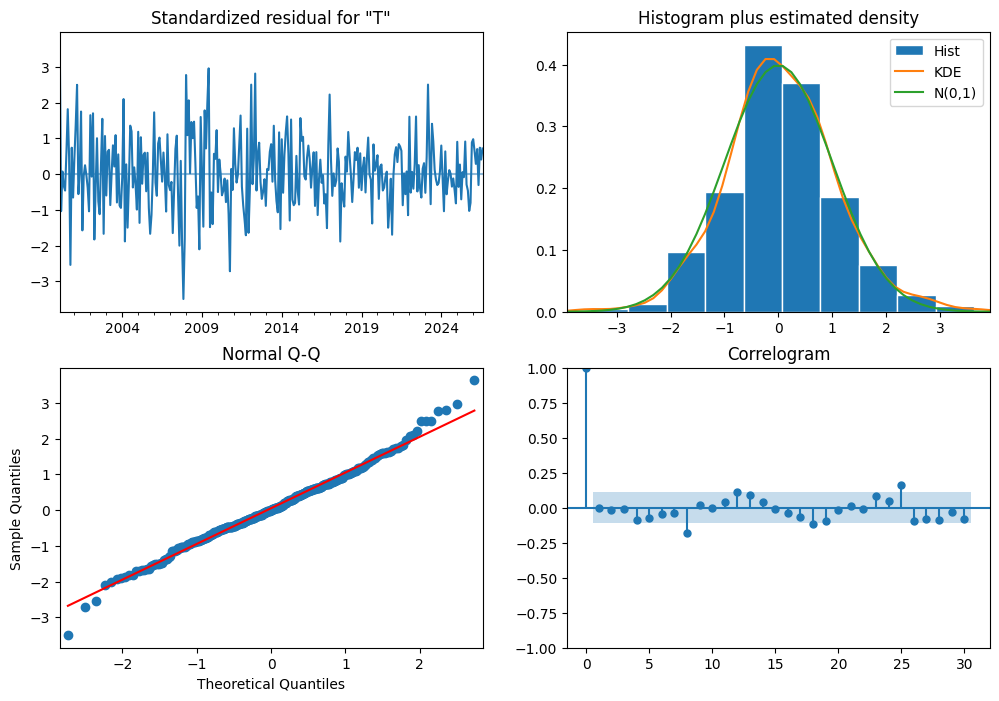

In [31]:
#Analisis Sisaan Model
model_arima1.plot_diagnostics(figsize=(12,8), lags=30)
plt.show()

In [32]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_arima1.resid, nlags=30)[1]

np.float64(0.002150024594789213)

In [33]:
model_arima1.test_heteroskedasticity('breakvar')

array([[3.40528036e-01, 6.40581017e-08]])

In [34]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(model_arima1.resid, correction=False)

(np.float64(0.562782949663834), np.float64(0.573582691998971))

In [35]:
from scipy.stats import jarque_bera

jb_stat, jb_pval = jarque_bera(model_arima1.resid)
print(jb_stat, jb_pval)

148582.3834946894 0.0


Terdapat masalah heteroskedastisitas (ragam sisaan tidak homogen), sehingga model belum bisa digunakan. Untuk menangani masalah ini dicoba dengan mengubah urutan penanganan ketidakstasioneran data, yaitu melakukan penanganan untuk nilaitengah terlebih dahulu dengan differencing.

In [36]:
temperature_diff2=pd.DataFrame(temperature.Temp.diff().dropna())

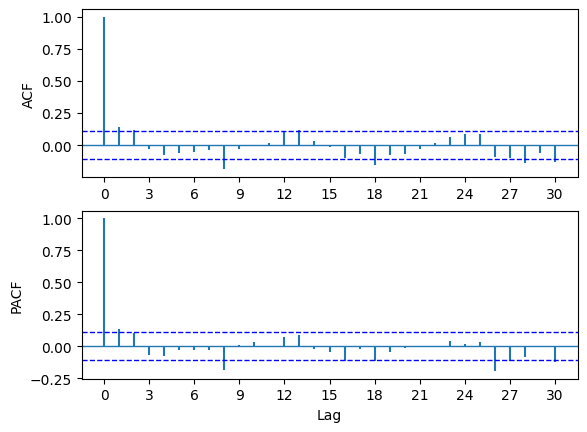

In [37]:
acf_pacf_fig(temperature_diff2, both=True, lag=30)

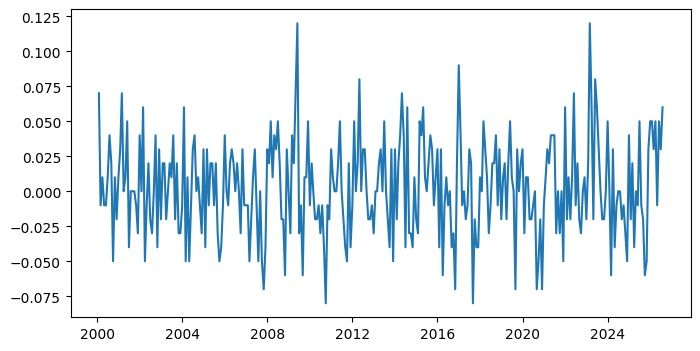

In [38]:
plt.figure(figsize=(8,4))
plt.plot(temperature_diff2)
plt.show()

In [39]:
from scipy.stats import boxcox,  boxcox_llf
temperature_diff2['positif'] = temperature_diff2['Temp'] - temperature_diff2['Temp'].min() + 1
data,lambda_fit,ci=boxcox(temperature_diff2.positif, alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  -1.1281239139758097
interval kepercayaan lambda: (-4.004912492148593, 1.7062559285331023)


Penerapan differencing ordo pertama terhadap data sudah mampu menangani ketidakstasioneran data dalam nilaitengah dan ragam sekaligus, sehingga tidak perlu dilakukan transformasi Boxcox.

In [40]:
%%R -i temperature_diff2.Temp
eacf(as.numeric(temperature_diff2.Temp))

AR/MA
  0 1 2 3 4 5 6 7 8 9 10 11 12 13
0 x x o o o o o x o o o  o  x  o 
1 x x o o o o o x o o o  o  o  o 
2 x x o o o o o x o o o  o  o  o 
3 x x x o o o o x o o o  o  o  o 
4 x x o o o o o x o o o  o  o  o 
5 x o o o o o o x o o o  o  o  o 
6 x o o x o x o x o o o  o  o  o 
7 x x o x o x x x o o o  o  o  o 


In [41]:
#model ARIMA (0,1,2)
model_arima4=ARIMA(temperature.Temp,order=(0,1,2)).fit()
print(model_arima4.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  320
Model:                 ARIMA(0, 1, 2)   Log Likelihood                 631.656
Date:                Tue, 29 Sep 2026   AIC                          -1257.311
Time:                        09:14:20   BIC                          -1246.016
Sample:                    01-01-2000   HQIC                         -1252.800
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1329      0.054      2.457      0.014       0.027       0.239
ma.L2          0.1516      0.057      2.647      0.008       0.039       0.264
sigma2         0.0011   8.66e-05     12.875      0.0

In [42]:
#model ARIMA (1,1,2)
model_arima5=ARIMA(temperature.Temp,order=(1,1,2)).fit()
print(model_arima5.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  320
Model:                 ARIMA(1, 1, 2)   Log Likelihood                 631.657
Date:                Tue, 29 Sep 2026   AIC                          -1255.313
Time:                        09:14:21   BIC                          -1240.252
Sample:                    01-01-2000   HQIC                         -1249.298
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0118      0.346      0.034      0.973      -0.667       0.690
ma.L1          0.1217      0.339      0.359      0.720      -0.543       0.787
ma.L2          0.1507      0.073      2.075      0.0

In [43]:
from statsmodels.stats.diagnostic import het_arch
het_arch(model_arima5.resid, nlags=30)[1]

np.float64(0.9128097115365639)

In [44]:
from statsmodels.sandbox.stats.runs import runstest_1samp
runstest_1samp(model_arima5.resid, correction=False)

(np.float64(0.0449042345679856), np.float64(0.9641836415540146))

In [45]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_test = acorr_ljungbox(model_arima5.resid, lags=[10, 20, 30], return_df=True)
print(ljung_box_test)

      lb_stat  lb_pvalue
10  10.504611   0.397391
20  25.936355   0.167924
30  42.488655   0.064955


Model ARIMA(0,1,2) merupakan model terbaik karena memenuhi semua uji diagnostik sisaan dn semua parameter signifikan. Selanjutnya dilakukan overfitting model dengan menambah ordo model.

In [46]:
#model overfitting ARIMA (0,1,3)
model_arima6=ARIMA(temperature.Temp,order=(0,1,3)).fit()
print(model_arima6.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  320
Model:                 ARIMA(0, 1, 3)   Log Likelihood                 631.657
Date:                Tue, 29 Sep 2026   AIC                          -1255.315
Time:                        09:14:22   BIC                          -1240.254
Sample:                    01-01-2000   HQIC                         -1249.300
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1343      0.055      2.431      0.015       0.026       0.243
ma.L2          0.1523      0.057      2.658      0.008       0.040       0.265
ma.L3          0.0034      0.053      0.064      0.9

In [57]:
#model overfitting ARIMA (1,1,2)
model_arima7=ARIMA(temperature.Temp,order=(1,1,2)).fit()
print(model_arima7.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  320
Model:                 ARIMA(1, 1, 2)   Log Likelihood                 631.657
Date:                Tue, 29 Sep 2026   AIC                          -1255.313
Time:                        09:22:09   BIC                          -1240.252
Sample:                    01-01-2000   HQIC                         -1249.298
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0118      0.346      0.034      0.973      -0.667       0.690
ma.L1          0.1217      0.339      0.359      0.720      -0.543       0.787
ma.L2          0.1507      0.073      2.075      0.0

Hasil model overfitting menunjukkan parameter ada yang tidak signifikan, sehingga model yang digunakan tetap model ARIMA(0,1,2).

### Peramalan

In [47]:
prediksi=model_arima5.get_forecast(4).summary_frame(alpha=0.05)

In [48]:
prediksi

Temp,mean,mean_se,mean_ci_lower,mean_ci_upper
2026-09-01,1.090737,0.033398,1.025278,1.156196
2026-10-01,1.098321,0.050484,0.999374,1.197269
2026-11-01,1.098411,0.066280,0.968505,1.228317
2026-12-01,1.098412,0.079009,0.943557,1.253268


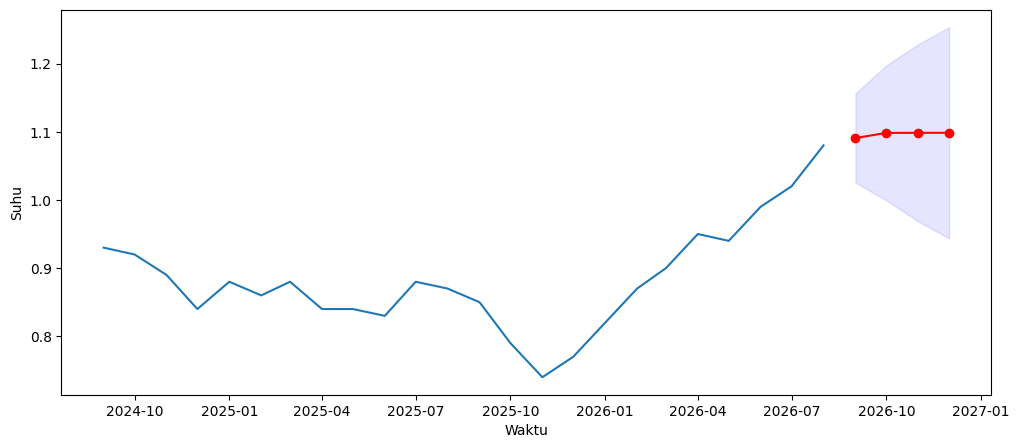

In [49]:
plt.figure(figsize=(12,5))
plt.plot(temperature.Temp[-24:])
plt.plot(prediksi['mean'],'-or')
plt.fill_between(prediksi.index,prediksi['mean_ci_lower'], prediksi['mean_ci_upper'], color='b', alpha=.1)
plt.xlabel('Waktu'), plt.ylabel('Suhu')
plt.show()

## AUTOARIMA

In [50]:
!pip install pmdarima

In [51]:
from pmdarima import auto_arima

In [52]:
arima_model=auto_arima(temperature.Temp,
start_p=0,
d=1,
start_q=0,
max_p=5,
max_q=5,
information_criterion='aic',
seasonal=False)

In [53]:
arima_model.order

(3, 1, 1)

In [54]:
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  320
Model:               SARIMAX(3, 1, 1)   Log Likelihood                 635.568
Date:                Tue, 29 Sep 2026   AIC                          -1259.135
Time:                        09:14:50   BIC                          -1236.544
Sample:                    01-01-2000   HQIC                         -1250.113
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0003      0.000      1.424      0.155      -0.000       0.001
ar.L1          1.0691      0.074     14.467      0.000       0.924       1.214
ar.L2         -0.0469      0.085     -0.552      0.5

In [58]:
print(het_arch(arima_model.resid(), nlags=30)[1])
print(runstest_1samp(arima_model.resid(), correction=False)[1])
print(jarque_bera(arima_model.resid())[1])

0.6823812253433041
0.9860266566162198
4.48431941914463e-175
